In [1]:
import polars as pl
from pathlib import Path
from textwrap import fill
import joblib
from glob import glob
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Apply shared publication style
import sys; sys.path.insert(0, str(Path('.').resolve()))
from pub_style import (apply_style, SITE_COLORS, add_panel_label, savefig,
                        FONT_SIZE_TITLE, FONT_SIZE_AXIS_LABEL, FONT_SIZE_LEGEND,
                        LINE_WIDTH, REFERENCE_LINE_WIDTH)
apply_style()

# Point to the data/ directory at repo root (download S3 data there)
DATA_DIR = Path('../data')

site_mapping = {
    'bidmc':'BIDMC',
    'stan':'Stanford',
    'emory':'Emory',
    'bch':'BCH',
    'mgb':'MGB',
}
model_type_mapping = {
    'nt1':'NT1',
    'nt2ih':'NT2/IH',
    'nt12':'NT1/2/IH',
}

In [2]:
features = pl.read_parquet(DATA_DIR / 'discriminative-modeling/features.parquet').hstack(
    pl.read_parquet(DATA_DIR / 'discriminative-modeling/notes.parquet').select('annot', 'cohort')
).filter(
    pl.col('annot') != 3 # unsure cases
).select(
    'id','date','cohort','annot', pl.all().exclude(['id','date','cohort','annot'])
)

In [3]:
all_models = {}
for model_type in ['nt1', 'nt2ih']:#, 'nt12']:

    # Load all your models
    rf_models = {}
    xgb_models = {}
    gb_models = {}  # your current models
    logistic_models = {}

    results_dir = DATA_DIR / f'results/{model_type}_vs_others'

    for m in glob(str(results_dir / 'fold_models_LogisticRegression/*.pkl')):
        logistic_models[m.split('/')[-1].split('_')[-1].split('.')[0]] = joblib.load(m)

    for m in glob(str(results_dir / 'fold_models_GradientBoosting/*.pkl')):
        gb_models[m.split('/')[-1].split('_')[-1].split('.')[0]] = joblib.load(m)

    for m in glob(str(results_dir / 'fold_models_RandomForest/*.pkl')):
        rf_models[m.split('/')[-1].split('_')[-1].split('.')[0]] = joblib.load(m)

    for m in glob(str(results_dir / 'fold_models_XGBoost/*.pkl')):
        xgb_models[m.split('/')[-1].split('_')[-1].split('.')[0]] = joblib.load(m)

    # Compare all three
    model_comparison = {
        'GradientBoosting': gb_models,
        'RandomForest': rf_models,
        'XGBoost': xgb_models,
        'LogisticRegression': logistic_models,
    }

    all_models[model_type] = model_comparison


Saved: figure1_roc_prc.png


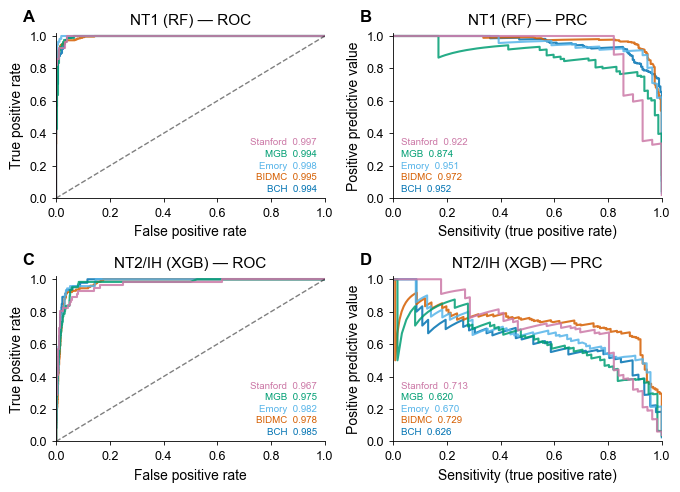

Saved: efigure3_nt1_all_models_roc_prc.png


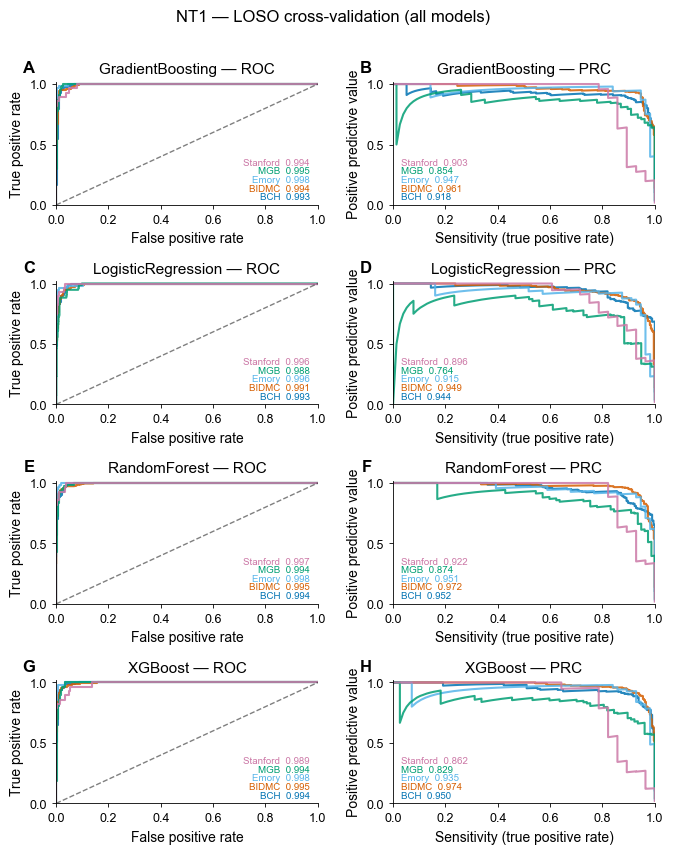

Saved: efigure4_nt2ih_all_models_roc_prc.png


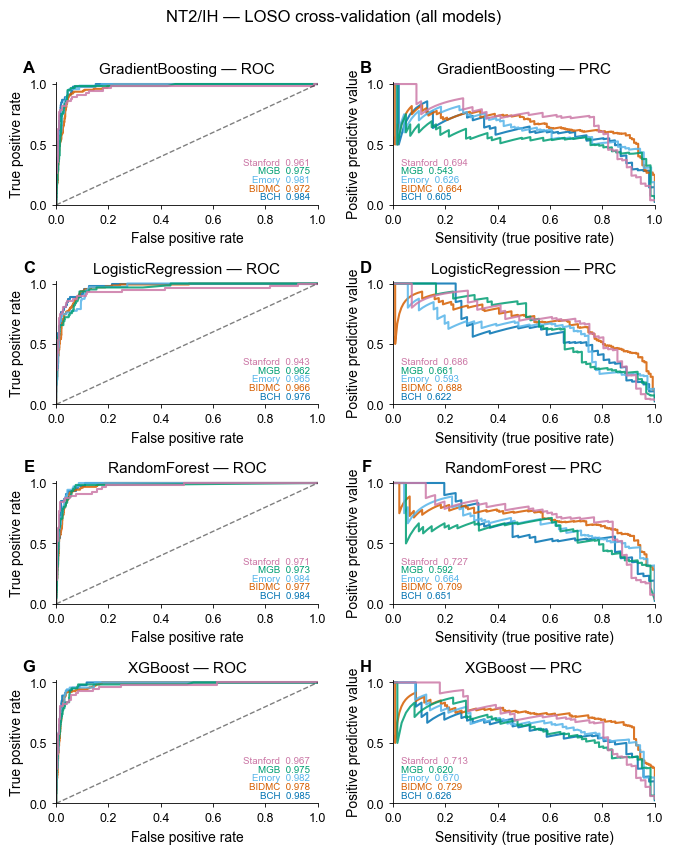

In [4]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc
from pub_style import FONT_SIZE_ANNOTATION
import re

MANUSCRIPT_FIG_DIR = Path('../manuscript/figures')
MANUSCRIPT_FIG_DIR.mkdir(parents=True, exist_ok=True)

# Best model per task (determined by highest mean AUROC + AUPRC balance)
BEST_MODEL = {'nt1': 'RandomForest', 'nt2ih': 'XGBoost'}
BEST_MODEL_SHORT = {'nt1': 'RF', 'nt2ih': 'XGB'}

SITE_ORDER = ['BCH', 'BIDMC', 'Emory', 'MGB', 'Stanford']

# Feature name sanitizer matching retrain_all.py
def _sanitize_col(c):
    return re.sub(r'[\[\]<>]', '_', c)

# Helper: plot ROC+PRC for one model on one axes pair
# Returns dict of {site_label: (auroc, auprc)} for the shared legend
def plot_roc_prc(model_comparison, model_name, model_type, feat, ax_roc, ax_prc):
    models = model_comparison[model_name]
    metrics = {}

    for test_site in sorted(models.keys()):
        model = models[test_site]
        expected_features = list(model.feature_names_in_)
        test_feat = feat.filter(pl.col('cohort') == test_site)
        y_test = test_feat[model_type].to_numpy()

        # Select and rename features to match model training
        X_cols = test_feat.drop(['annot', 'cohort', 'id', 'date', model_type])
        rename_map = {c: _sanitize_col(c) for c in X_cols.columns if _sanitize_col(c) != c}
        if rename_map:
            X_cols = X_cols.rename(rename_map)
        X_test = X_cols.select(expected_features)

        y_prob = model.predict_proba(X_test)[:, 1]
        site_label = site_mapping[test_site]
        color = SITE_COLORS[site_label]

        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        ax_roc.plot(fpr, tpr, color=color, alpha=0.85, linewidth=LINE_WIDTH)

        precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
        pr_auc = auc(recall_vals, precision_vals)
        ax_prc.plot(recall_vals, precision_vals, color=color, alpha=0.85,
                    linewidth=LINE_WIDTH)
        metrics[site_label] = (roc_auc, pr_auc)

    ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=REFERENCE_LINE_WIDTH, alpha=0.5)
    ax_roc.set_xlabel('False positive rate')
    ax_roc.set_ylabel('True positive rate')
    ax_roc.set_xlim([0, 1]); ax_roc.set_ylim([0, 1.02])

    ax_prc.set_xlabel('Sensitivity (true positive rate)')
    ax_prc.set_ylabel('Positive predictive value')
    ax_prc.set_xlim([0, 1]); ax_prc.set_ylim([0, 1.02])

    # Compact color-coded metric text inside each panel
    # ROC: lower-right; PRC: lower-left
    line_h = 0.07  # spacing between lines in axes coords
    for i, s in enumerate(SITE_ORDER):
        color = SITE_COLORS[s]
        ax_roc.text(0.97, 0.03 + i * line_h, f'{s}  {metrics[s][0]:.3f}',
                    transform=ax_roc.transAxes, fontsize=FONT_SIZE_ANNOTATION,
                    va='bottom', ha='right', color=color)
        ax_prc.text(0.03, 0.03 + i * line_h, f'{s}  {metrics[s][1]:.3f}',
                    transform=ax_prc.transAxes, fontsize=FONT_SIZE_ANNOTATION,
                    va='bottom', ha='left', color=color)

    return metrics

# Prepare feature frames
feat_frames = {}
for model_type in ['nt1', 'nt2ih']:
    feat = features.clone()
    if model_type == 'nt1':
        feat = feat.with_columns(
            pl.when(pl.col('annot') == 1).then(1).otherwise(0).alias('nt1'))
    elif model_type == 'nt2ih':
        feat = feat.with_columns(
            pl.when(pl.col('annot') == 2).then(1).otherwise(0).alias('nt2ih'))
    feat_frames[model_type] = feat

# ============================================================
# FIGURE 1: Best model only — 2x2 (NT1 top, NT2/IH bottom)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(6.875, 5.0))

for row_idx, model_type in enumerate(['nt1', 'nt2ih']):
    label = model_type_mapping[model_type]
    best = BEST_MODEL[model_type]
    short = BEST_MODEL_SHORT[model_type]
    ax_roc, ax_prc = axes[row_idx, 0], axes[row_idx, 1]

    plot_roc_prc(all_models[model_type], best, model_type,
                 feat_frames[model_type], ax_roc, ax_prc)

    ax_roc.set_title(f'{label} ({short}) — ROC')
    ax_prc.set_title(f'{label} ({short}) — PRC')

    panel_row = [['A', 'B'], ['C', 'D']][row_idx]
    add_panel_label(ax_roc, panel_row[0])
    add_panel_label(ax_prc, panel_row[1])

plt.tight_layout()
savefig(fig, str(MANUSCRIPT_FIG_DIR / 'figure1_roc_prc.png'))
print('Saved: figure1_roc_prc.png')
plt.show()

# ============================================================
# eFIGURES 3-4: All models (full 4x2 comparison grids)
# ============================================================
efig_name_map = {'nt1': 'efigure3_nt1_all_models_roc_prc.png',
                 'nt2ih': 'efigure4_nt2ih_all_models_roc_prc.png'}
panel_labels_4x2 = [['A','B'], ['C','D'], ['E','F'], ['G','H']]

for model_type in ['nt1', 'nt2ih']:
    model_comparison = all_models[model_type]
    feat = feat_frames[model_type]
    label = model_type_mapping[model_type]
    model_names = sorted(model_comparison.keys())
    n_models = len(model_names)

    fig, axes = plt.subplots(n_models, 2, figsize=(6.875, 2.1 * n_models))
    if n_models == 1:
        axes = axes.reshape(1, -1)

    for m_idx, model_name in enumerate(model_names):
        ax_roc, ax_prc = axes[m_idx, 0], axes[m_idx, 1]
        add_panel_label(ax_roc, panel_labels_4x2[m_idx][0])
        add_panel_label(ax_prc, panel_labels_4x2[m_idx][1])

        plot_roc_prc(model_comparison, model_name, model_type, feat, ax_roc, ax_prc)
        ax_roc.set_title(f'{model_name} — ROC')
        ax_prc.set_title(f'{model_name} — PRC')

    fig.suptitle(f'{label} — LOSO cross-validation (all models)',
                 fontsize=FONT_SIZE_TITLE + 1, y=1.01)
    plt.tight_layout()
    savefig(fig, str(MANUSCRIPT_FIG_DIR / efig_name_map[model_type]))
    print(f'Saved: {efig_name_map[model_type]}')
    plt.show()